**Norm-fix rerun** of `wrappers/qwen_analysis/1_loudest_layer/qwen_p2_loudest_layer.ipynb` (Qwen final norm `1 + w`). Substitutions: `Path("/workspace/loudness_evaluation/qwen_p2_layer_profile")` → `Path("/workspace/loudness_evaluation/qwen_p2_layer_profile_fixnorm")`

# Qwen P2 — direction loudness per layer

Which layer is most direction-loaded, over the whole dataset. The answer pins
`--select-candidate-layers` for the selecting gather that follows.

Input is what `wrappers/qwen_analysis/loudest_layer/join_loudness_profile.sh` writes: one
row per reasoning token, one `L{layer}` column per layer, each cell `log P(any direction
word)` at that (token, layer).

An **empty** cell means the lens did not cover that layer (the jlens outside its fitted
range) — not "no mass here". It becomes `NaN` and is skipped by the mean, which is the
intended behaviour; a layer's mean is over the tokens it actually covers.

In [1]:
# 1. imports and load the joined tables
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUT_DIR = Path("/workspace/loudness_evaluation/qwen_p2_layer_profile_fixnorm")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# keep_default_na=False: decoded tokens include the literal string "NA" and empty
# strings, which pandas would otherwise turn into missing values.
jlens = pd.read_csv(OUT_DIR / "jlens_tokens.csv", keep_default_na=False, low_memory=False)
logitlens = pd.read_csv(OUT_DIR / "logitlens_tokens.csv", keep_default_na=False, low_memory=False)

print(f"jlens:     {len(jlens):,} token rows, {jlens.trajectory.nunique():,} trajectories")
print(f"logitlens: {len(logitlens):,} token rows, {logitlens.trajectory.nunique():,} trajectories")
jlens.head()

jlens:     460,484 token rows, 549 trajectories
logitlens: 460,484 token rows, 549 trajectories


,trajectory,size,complexity,run,step,reasoning_pos,abs_pos,token,agent_action,L3,L7,L11,L15,L19,L23,L27,L31,L35,L39
0,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,4,551,Ġto,DOWN,-5.340994,-5.852754,-6.323377,-6.935554,-7.412326,-8.964870,-10.306940,-11.424835,-13.545178,-18.077919
1,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,55,602,).,DOWN,-10.377638,-8.763582,-6.886493,-7.016651,-7.836895,-8.455908,-9.250992,-11.120228,-15.002351,-19.314709
2,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,113,660,#,DOWN,-17.312649,-18.880878,-19.066128,-15.735535,-12.608618,-10.940649,-7.081209,-6.463983,-13.511683,-22.218117
3,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,131,678,#,DOWN,-17.498531,-19.473917,-18.961460,-16.164608,-13.662764,-10.381220,-7.599943,-5.905122,-14.184205,-23.460369
4,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,143,690,Ċ,DOWN,-5.405366,-4.740799,-5.726266,-6.673814,-6.666767,-7.125073,-8.266254,-8.953052,-19.955507,-19.224844


In [2]:
# 2. aggregate at row level — every token is one observation
def layer_columns(df):
    """The L{layer} columns, in layer order."""
    cols = [c for c in df.columns if c.startswith("L") and c[1:].isdigit()]
    return sorted(cols, key=lambda c: int(c[1:]))


def loudness_matrix(df):
    """Just the layer columns, numeric. Empty cells (layer not covered) become NaN."""
    cols = layer_columns(df)
    return df[cols].apply(pd.to_numeric, errors="coerce")


jlens_mass = loudness_matrix(jlens)
logitlens_mass = loudness_matrix(logitlens)

print("layers:", [int(c[1:]) for c in layer_columns(jlens)])
print(f"jlens rows: {len(jlens_mass):,}   logitlens rows: {len(logitlens_mass):,}")

layers: [3, 7, 11, 15, 19, 23, 27, 31, 35, 39]
jlens rows: 460,484   logitlens rows: 460,484


In [3]:
# 3. mean direction loudness per layer
def mean_per_layer(mass):
    """{layer: mean loudness}, as a Series indexed by integer layer."""
    means = mass.mean()  # skips NaN
    means.index = [int(c[1:]) for c in means.index]
    return means.sort_index()


jlens_per_layer = mean_per_layer(jlens_mass)
logitlens_per_layer = mean_per_layer(logitlens_mass)

print(f"jlens argmax layer:     {jlens_per_layer.idxmax()}  ({jlens_per_layer.max():.4f})")
print(f"logitlens argmax layer: {logitlens_per_layer.idxmax()}  ({logitlens_per_layer.max():.4f})")
pd.DataFrame({"jlens": jlens_per_layer, "logitlens": logitlens_per_layer})

jlens argmax layer:     27  (-7.2781)
logitlens argmax layer: 2  (-5.6397)


,jlens,logitlens
0,NaN,-5.671785
1,NaN,-5.683115
2,NaN,-5.639680
3,-8.038894,-5.752953
4,NaN,-5.790745
5,NaN,-5.813008
6,NaN,-5.812721
7,-7.571703,-5.848437
8,NaN,-5.899301
9,NaN,-5.992413


saved /workspace/loudness_evaluation/qwen_p2_layer_profile_fixnorm/figures/jlens_loudness_per_layer.png


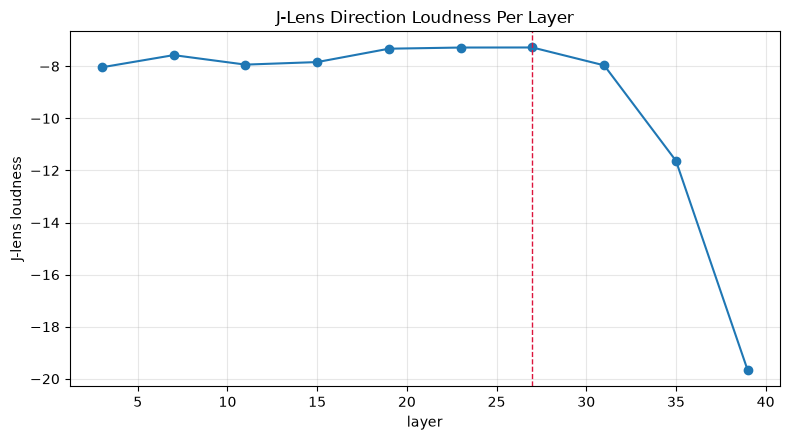

In [4]:
# 4. J-Lens Direction Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(jlens_per_layer.index, jlens_per_layer.values, marker="o")
ax.axvline(jlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("J-Lens Direction Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("J-lens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "jlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "jlens_loudness_per_layer.png")
plt.show()

saved /workspace/loudness_evaluation/qwen_p2_layer_profile_fixnorm/figures/logitlens_loudness_per_layer.png


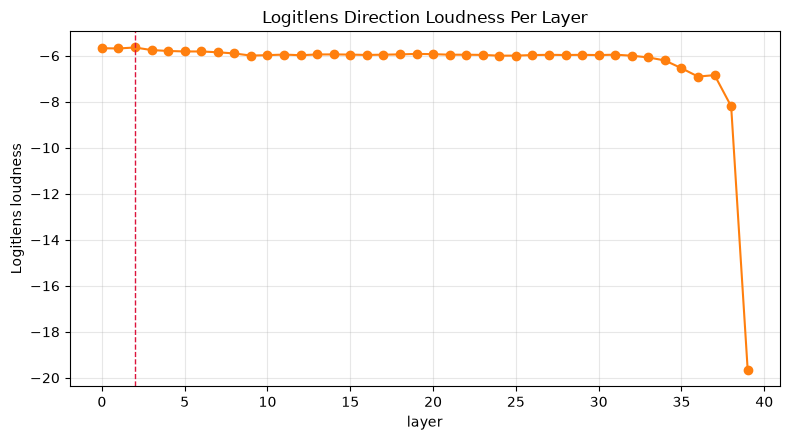

In [5]:
# 5. Logitlens Direction Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(logitlens_per_layer.index, logitlens_per_layer.values, marker="o", color="tab:orange")
ax.axvline(logitlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("Logitlens Direction Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("Logitlens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "logitlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "logitlens_loudness_per_layer.png")
plt.show()